## 1. A basic chatbot

In [1]:
import pandas as pd
import numpy as np
import re
import string
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 2. Datasets 

In [2]:
df_csv = pd.read_csv("Datasets/full_dataset.csv")
df_csv = df_csv.rename(columns={"input": "question", "target": "answer"})
df_txt = pd.read_csv("Datasets/dialogs.txt", sep='\t', header=None, names=["question", "answer"])
df_greetings = pd.read_csv("Datasets/chatbot_greetings_dataset.csv")
df_greetings = df_greetings[["input", "response"]].rename(columns={"input": "question", "response": "answer"})
df = pd.concat([df_greetings, df_csv, df_txt], ignore_index=True)
df = df.dropna()

print(df.shape)
df.head()

(26645, 2)


,question,answer
0,Hi,Hello! How can I help you today?
1,Hello,Hi there! What can I do for you?
2,Hey,Hey! How's it going?
3,Hi there,Hi! Great to see you. What's on your mind?
4,Hello there,Hello! Hope you're having a wonderful day. How...


In [3]:
print(len(df['answer'].unique()))

6566


## 3. Text preprocessing

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_question"] = df["question"].apply(clean_text)
df.head()

,question,answer,clean_question
0,Hi,Hello! How can I help you today?,hi
1,Hello,Hi there! What can I do for you?,hello
2,Hey,Hey! How's it going?,hey
3,Hi there,Hi! Great to see you. What's on your mind?,hi there
4,Hello there,Hello! Hope you're having a wonderful day. How...,hello there


## 4. Fine-Tune DistilBERT for Intent Classification

In [5]:
import spacy

try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading 'en_core_web_md' model for SpaCy...")
    from spacy.cli import download
    download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

def get_similarity(text1, text2):
    return nlp(str(text1)).similarity(nlp(str(text2)))

# Pre-compute vectors for all dataset questions
# nlp.pipe yields generator of Docs, we take .vector for each
df["question_vector"] = list(doc.vector for doc in nlp.pipe(df["clean_question"]))
question_matrix = np.vstack(df["question_vector"].values)

print("Spacy Question Vectors Shape:", question_matrix.shape)

SystemExit: 2

C:\Users\LOQ\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 5. Response function

In [ ]:
def calculate_math(expression):
    match = re.search(r'(\d+(?:\.\d+)?)\s*([\+\-\*\/])\s*(\d+(?:\.\d+)?)', expression)
    if match:
        num1 = float(match.group(1))
        op = match.group(2)
        num2 = float(match.group(3))
        
        if op == '+':
            return num1 + num2
        elif op == '-':
            return num1 - num2
        elif op == '*':
            return num1 * num2
        elif op == '/':
            if num2 != 0:
                return num1 / num2
            else:
                return "Cannot divide by zero"
    return None

# Store globally 
chat_history = []

def chatbot_response(user_input, threshold=0.6, use_history=True):
    global chat_history
    
    cleaned_input = clean_text(user_input)
    response_text = ""
    
    # 1. Simple Intent Matching
    greeting_keywords = ['hello', 'hi', 'hey', 'greetings', 'sup', 'whatsup']
    farewell_keywords = ['bye', 'goodbye', 'see ya', 'cya', 'farewell']
    

    words = cleaned_input.split()
    is_greeting = any(word in greeting_keywords for word in words) and len(words) < 5
    is_farewell = any(word in farewell_keywords for word in words) and len(words) < 5
    math_result = calculate_math(user_input)
    

    if math_result is not None:
        response_text = f"Chatbot [Math] : The answer is {math_result}"
        print("Predicted Intent: 'math' (Rule-Based)")
        
    elif is_greeting:
        greetings = ["Hello there!", "Hi! How can I help you?", "Greetings! Whats up?", "Hey!"]
        response_text = f"Chatbot [Greeting] : {random.choice(greetings)}"
        print("Predicted Intent: 'greeting' (Rule-Based)")
        
    elif is_farewell:
        farewells = ["Goodbye!", "See you later!", "Have a great day!", "Take care!"]
        response_text = f"Chatbot [Farewell] : {random.choice(farewells)}"
        print("Predicted Intent: 'farewell' (Rule-Based)")
        
    else:
        print("Predicted Intent: 'general_qa' (Default/Fallback)")
        search_query = cleaned_input
        
        if use_history and len(chat_history) > 0 and len(cleaned_input.split()) <= 3:
            last_query = chat_history[-1]['user']
            search_query = f"{clean_text(last_query)} {cleaned_input}"
            print(f"    -> Using context-aware query: '{search_query}'")

        input_vector = nlp(search_query).vector.reshape(1, -1)
        
        # Calculate cosine similarity with all pre-computed Spacy question vectors
        similarities = cosine_similarity(input_vector, question_matrix).flatten()
        
        best_sim_idx = np.argmax(similarities)
        best_sim_score = similarities[best_sim_idx]
        
        if best_sim_score < threshold:
            response_text = "Chatbot [GeneralQA] : Sorry, I'm not sure how to answer that. Could you rephrase?"
        else:
            print(f"    -> QA best match score (Spacy Similarity): {best_sim_score:.2f}")
            response_text = f"Chatbot [GeneralQA] : {df['answer'].iloc[best_sim_idx]}"

    # Append to history
    chat_history.append({'user': user_input, 'bot': response_text})
    if len(chat_history) > 5:
        chat_history.pop(0)
        
    return response_text

## 6. Prediction Confidence Visualization

C:\Users\LOQ\AppData\Local\Temp\ipykernel_2744\1019390851.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_questions, palette="Blues_d", orient='h')


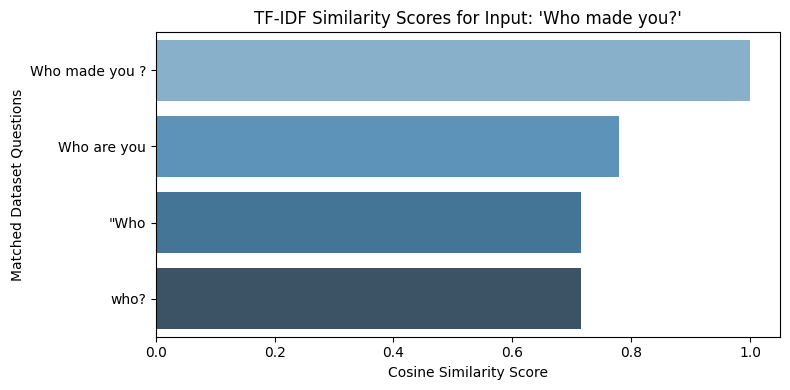

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_confidence(user_input, top_n=4):
    cleaned_input = clean_text(user_input)
    
    input_vector = nlp(cleaned_input).vector.reshape(1, -1)
    similarities = cosine_similarity(input_vector, question_matrix).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    top_scores = similarities[top_indices]
    
    top_questions = df['question'].iloc[top_indices].values
    
    # limit text length for graphing
    top_questions = [q[:30] + ("..." if len(q)>30 else "") for q in top_questions]
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_scores, y=top_questions, palette="Blues_d", orient='h')
    plt.title(f"Spacy Vector Similarity Scores for Input: '{user_input}'")
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Matched Dataset Questions")
    plt.tight_layout()
    plt.show()

visualize_confidence("Who made you?")

## 7. Chat loop, skip this one by typing "exit" , it was only for testing

In [ ]:
print("Type 'quit' to exit.\n")
print("-" * 50)

while True:
    user_input = input("You: ")
    
    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("Chatbot : Goodbye! Have a great day!")
        break
    
    if user_input.strip() == "":
        continue
        
    response = chatbot_response(user_input)
    print(f"\n{response}\n")
    print("-" * 50)

Type 'quit' to exit.

--------------------------------------------------
Predicted Intent: 'general_qa' (Default/Fallback)
    -> QA best match score (TF-IDF): 1.00

Chatbot [GeneralQA] : Shreshtha, a.k.a Siri

--------------------------------------------------
Predicted Intent: 'general_qa' (Default/Fallback)
    -> QA best match score (TF-IDF): 0.70

Chatbot [GeneralQA] : Shreshtha, a.k.a Siri

--------------------------------------------------
Predicted Intent: 'general_qa' (Default/Fallback)
    -> QA best match score (TF-IDF): 0.50

Chatbot [GeneralQA] : I'm a conversational AI assistant here to help you with questions and more!

--------------------------------------------------
Chatbot : Goodbye! Have a great day!


## 9. Evaluation Metrics

In [ ]:
import spacy
from sklearn.model_selection import train_test_split

try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading 'en_core_web_md' model for SpaCy...")
    from spacy.cli import download
    download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

def get_similarity(text1, text2):
    return nlp(str(text1)).similarity(nlp(str(text2)))


train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

print("Starting Evaluation using Spacy Word Embeddings...")

train_df = train_df.copy()
train_df["question_vector"] = list(doc.vector for doc in nlp.pipe(train_df["clean_question"]))
train_vector_matrix = np.vstack(train_df["question_vector"].values)

def evaluate_bot_spacy(test_data):
    correct_exact_matches = 0
    total_similarity = 0
    
    total_test = min(len(test_data), 200) 
    
    print(f"Evaluating exact matches and semantic similarity on {total_test} samples...")
    for idx, row in test_data.head(total_test).iterrows():
        question = row['question']
        expected_answer = row['answer']
        
        cleaned_input = clean_text(question)
        input_vector = nlp(cleaned_input).vector.reshape(1, -1)
        similarities = cosine_similarity(input_vector, train_vector_matrix).flatten()
        best_sim_idx = np.argmax(similarities)
        
        predicted_answer = train_df['answer'].iloc[best_sim_idx]
        
        if predicted_answer == expected_answer:
            correct_exact_matches += 1
            

        sim_score = get_similarity(predicted_answer, expected_answer)
        total_similarity += sim_score
            
    accuracy = correct_exact_matches / total_test
    avg_similarity = total_similarity / total_test
    
    print(f"\n--- Evaluation Results ---")
    print(f"Exact Match Accuracy: {accuracy:.4f}")
    print(f"Average SpaCy Semantic Similarity: {avg_similarity:.4f}")

evaluate_bot_spacy(test_df)

Starting Simple Evaluation using TF-IDF...
Evaluating exact matches on 2000 samples...

--- Simple TF-IDF Exact Match Accuracy ---
Estimated Accuracy on test set: 0.0370
